# El mercado en Python
### Clase 1: Práctica
**Finanzas Cuantitativas, la Ciencia y los Mercados**
FCEN-UBA · Guido Schifani

---


| Ejercicio | Tema | Qué hacemos |
|---|---|---|
| **1** | Datos | yfinance: OHLCV, `Close` vs `Adj Close` |
| **2** | Renta fija | Precio de un bono, duration, convexidad y YTM |
| **3** | Curvas | Calibrar Nelson-Siegel-Svensson y bootstrapear: Tesoro USA y bonos argentinos → riesgo país |
| **4** | Swaps | Valuar un IRS con la curva del Ej. 3: par swap rate, MTM y DV01 |
| **5** | FX | Covered Interest Parity: spot, futuro de euro y la tasa EUR implícita |
| **6** | Tasas *(extra)* | La Fed y la transición LIBOR→SOFR: de encuesta a transacción real |



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import brentq
import yfinance as yf

plt.rcParams['figure.figsize'] = (12, 4)

---
# Ejercicio 1, La base de todo datos con yfinance



## 1. Bajar un ticker y mirar la forma de los datos
Un **ticker** es el código que identifica al instrumento: `SPY` (ETF del S&P 500), `AAPL` (Apple), `^GSPC` (índice S&P 500), `BTC-USD` (bitcoin), `EURUSD=X` (dólar/euro).

In [2]:
df = yf.download('SPY', start='2023-01-01', end='2023-04-01', auto_adjust=False, progress=False)


print('Columnas:', list(df.columns))
df.head()

Columnas: [('Adj Close', 'SPY'), ('Close', 'SPY'), ('High', 'SPY'), ('Low', 'SPY'), ('Open', 'SPY'), ('Volume', 'SPY')]


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY,SPY
Date,,,,,,
2023-01-03,364.133972,380.820007,386.429993,377.829987,384.369995,74850700
2023-01-04,366.945190,383.760010,385.880005,380.000000,383.179993,85934100
2023-01-05,362.757050,379.380005,381.839996,378.760010,381.720001,76970500
2023-01-06,371.075867,388.079987,389.250000,379.410004,382.609985,104189600
2023-01-09,370.865509,387.859985,393.700012,387.670013,390.369995,73978100


## 2. La estructura: índice de fechas + columnas OHLCV
Cada **fila es un día de mercado** (no hay fines de semana ni feriados). El **índice** es de tipo fecha (`DatetimeIndex`). Las columnas son el estándar **OHLCV**:

| Columna | Qué es |
|---|---|
| **Open** | Precio de apertura del día |
| **High** | Máximo del día |
| **Low** | Mínimo del día |
| **Close** | Precio de cierre |
| **Adj Close** | Cierre **ajustado** por dividendos y splits |
| **Volume** | Cantidad de acciones operadas |

In [3]:

# Resumen rápido de cada columna
df.describe().round(2)

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY,SPY
count,62.00,62.00,62.00,62.00,62.00,6.200000e+01
mean,381.76,398.98,401.49,395.78,398.35,9.184743e+07
std,8.33,8.75,8.39,8.76,8.46,2.710712e+07
min,362.76,379.38,381.84,377.83,381.72,5.952490e+07
25%,377.39,393.31,396.15,390.14,392.34,7.405830e+07
50%,380.93,398.38,400.92,395.93,398.61,8.637295e+07
75%,387.80,405.45,407.22,402.20,404.34,1.010211e+08
max,398.52,416.78,418.31,412.88,414.86,1.892530e+08


## 3. `Close` vs `Adj Close`
El **cierre ajustado** corrige el precio hacia atrás por **dividendos** y **splits**. Para calcular retornos **siempre** se usa el ajustado (o `auto_adjust=True`): si no, un pago de dividendo aparece como una caída del precio que **no** es una pérdida real.

Por eso en el resto del notebook usamos `auto_adjust=True` (Yahoo ya devuelve el `Close` ajustado).

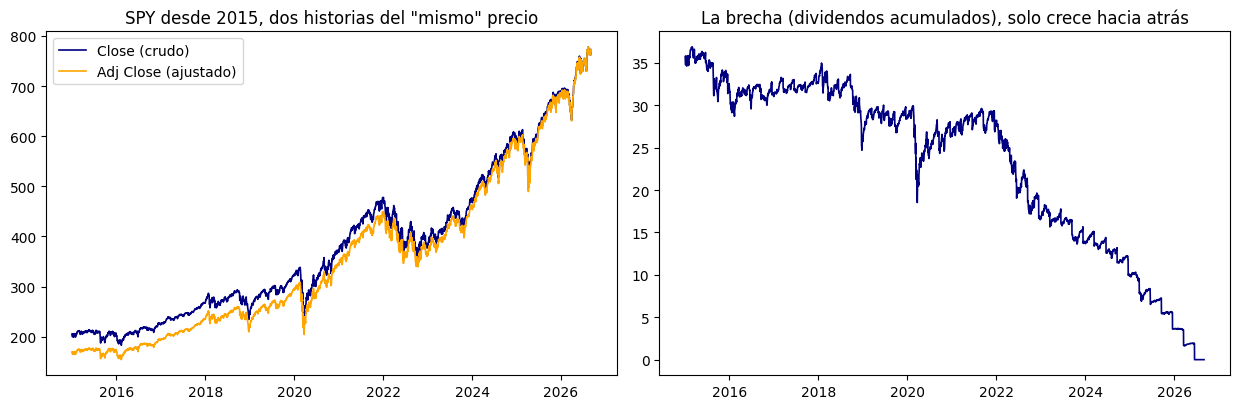

Retorno total de SPY desde 2015 usando Close crudo:  +274.9%
Retorno total de SPY desde 2015 usando Adj Close:    +353.9%
La diferencia son los dividendos: usar el crudo SUBESTIMA el retorno real.
(El ajuste es hacia atrás: hoy coinciden, y la brecha crece hacia el pasado.)


In [4]:
# La diferencia entre crudo y ajustado se ACUMULA: cada dividendo agranda la brecha
spy_largo = yf.download('SPY', start='2015-01-01', auto_adjust=False, progress=False)
cierre   = spy_largo['Close'].squeeze().dropna()
ajustado = spy_largo['Adj Close'].squeeze().dropna()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
axes[0].plot(cierre.index, cierre, color='navy', lw=1.2, label='Close (crudo)')
axes[0].plot(ajustado.index, ajustado, color='orange', lw=1.2, label='Adj Close (ajustado)')
axes[0].legend(); axes[0].set_title('SPY desde 2015, dos historias del "mismo" precio')
axes[1].plot(cierre.index, cierre - ajustado, color='navy', lw=1.2)
axes[1].set_title('La brecha (dividendos acumulados), solo crece hacia atrás')
plt.tight_layout(); plt.show()

# El número que importa: el retorno total según cuál uses
ret_crudo = float(cierre.iloc[-1] / cierre.iloc[0]) - 1
ret_ajust = float(ajustado.iloc[-1] / ajustado.iloc[0]) - 1
print(f'Retorno total de SPY desde 2015 usando Close crudo:  {ret_crudo:+.1%}')
print(f'Retorno total de SPY desde 2015 usando Adj Close:    {ret_ajust:+.1%}')
print('La diferencia son los dividendos: usar el crudo SUBESTIMA el retorno real.')
print('(El ajuste es hacia atrás: hoy coinciden, y la brecha crece hacia el pasado.)')

### La cuenta exacta del ajuste

El `Adj Close` es una **corrección multiplicativa hacia atrás**.
Cada vez que hay un dividendo $D$ con fecha ex-dividendo $t_{ex}$, todos los precios **anteriores**
a esa fecha se multiplican por un factor:

$$f_{ex} = 1 - \frac{D}{P^{close}_{ex-1}} \qquad\Longrightarrow\qquad AdjClose_t = Close_t \times \prod_{t_{ex} > t} f_{ex}$$

donde $P^{close}_{ex-1}$ es el cierre del día anterior al ex-date. La lógica: el día ex-dividendo
el precio abre ~$D$ más abajo (el que compra ese día ya no cobra el dividendo) , 
el factor "borra" ese escalón para que la serie ajustada solo refleje movimientos económicos reales.
Los ajustes se **componen**: un precio de hace 10 años acumula el producto de todos los factores
de los dividendos que vinieron después.

(Para un split $k$:1 el factor es $1/k$. Yahoo ya trae el `Close` ajustado por splits,
así que el `Adj Close` solo agrega la capa de dividendos. SPY nunca hizo split, ideal para el demo.)

Bajamos los dividendos reales de SPY, armamos los factores a mano para los 46 dividendos
desde 2015 (el mismo período de la brecha de arriba, no un recorte), y comparamos nuestra
serie contra el `Adj Close` de Yahoo, y contra el propio producto de los factores, sin promediar nada.

In [5]:
# ── Replicar el Adj Close a mano: TODOS los factores reales desde 2015 ───────
divs = yf.Ticker('SPY').dividends                      # dividendos reales, con su ex-date
divs.index = divs.index.tz_localize(None).normalize()  # emparejar zona horaria con el índice de precios
divs = divs[divs.index >= cierre.index.min()]

adj_propio = cierre.copy()
factores = []
for fecha, D in divs.items():
    previos = cierre.index[cierre.index < fecha]
    c_prev  = float(cierre.loc[previos[-1]])           # cierre del día ANTERIOR al ex-date
    f = 1 - D / c_prev                                 # el factor de ajuste de este dividendo
    adj_propio.loc[cierre.index < fecha] *= f          # se aplica a TODO lo anterior (se componen)
    factores.append((fecha.date(), D, c_prev, f))

tabla = pd.DataFrame(factores, columns=['ex-date', 'D ($)', 'cierre t-1', 'factor'])
print(f'{len(tabla)} dividendos entre {cierre.index.min().date()} y hoy, primeros y últimos 5 (el resto compone igual):')
print(pd.concat([tabla.head(5), tabla.tail(5)]).to_string(
    index=False,
    formatters={'D ($)': '{:.3f}'.format, 'cierre t-1': '{:.2f}'.format, 'factor': '{:.6f}'.format}))

dif = (adj_propio - ajustado).dropna().abs()
print(f'\nMáxima diferencia |nuestro ajustado − Adj Close de Yahoo|: {dif.max():.4f} USD')

# La cuenta EXACTA (nada de promediar un factor y elevarlo a una potencia):
# el producto de los factores reales, uno por uno, tiene que reconciliar los dos retornos de la celda anterior.
F_exacto = tabla['factor'].prod()
F_implicito = (1 + ret_crudo) / (1 + ret_ajust)
print(f'\nProducto de los {len(tabla)} factores reales:                 {F_exacto:.4f}')
print(f'Factor implícito por los retornos (1+r_crudo)/(1+r_ajust): {F_implicito:.4f}')


46 dividendos entre 2015-01-02 y hoy, primeros y últimos 5 (el resto compone igual):
   ex-date D ($) cierre t-1   factor
2015-03-20 0.931     209.50 0.995556
2015-06-19 1.030     212.78 0.995159
2015-09-18 1.033     199.73 0.994828
2015-12-18 1.212     204.86 0.994084
2016-03-18 1.050     204.63 0.994869
2025-06-20 1.761     597.44 0.997052
2025-09-19 1.831     662.26 0.997235
2025-12-19 1.993     676.47 0.997054
2026-03-20 1.797     659.80 0.997276
2026-06-18 1.904     740.96 0.997430

Máxima diferencia |nuestro ajustado − Adj Close de Yahoo|: 0.0002 USD

Producto de los 46 factores reales:                 0.8260
Factor implícito por los retornos (1+r_crudo)/(1+r_ajust): 0.8260


## 4. Qué MÁS se puede obtener: el objeto `Ticker`
`yf.Ticker(...)` da acceso a metadatos, dividendos, splits y fundamentales.

In [6]:
spy_tk = yf.Ticker('SPY')

# Metadatos (.info es un dict grande; miramos algunas claves)
info = spy_tk.info
for k in ['longName', 'quoteType', 'currency', 'exchange']:
    print(f'{k:12s}: {info.get(k)}')

# Dividendos y splits históricos
print('\nÚltimos dividendos:')
print(spy_tk.dividends.tail(3).to_string())

longName    : State Street SPDR S&P 500 ETF Trust
quoteType   : ETF
currency    : USD
exchange    : PCX

Últimos dividendos:
Date
2025-12-19 09:30:00-05:00    1.993
2026-03-20 09:30:00-04:00    1.797
2026-06-18 09:30:00-04:00    1.904


## 5. Otras frecuencias y varios tickers a la vez
Con `interval` cambiás la frecuencia: `'1d'`, `'1wk'`, `'1mo'`, o intradía (`'1h'`, `'5m'`, `'1m'`).
Cuanto más fina la barra, menos historia guarda Yahoo hacia atrás, el minuto a minuto solo
cubre las últimas semanas, así que para intradía real (clase 7) se necesitan otras fuentes.

In [7]:
# Mensual, un año
mensual = yf.download('SPY', start='2023-01-01', end='2024-01-01', interval='1mo', auto_adjust=True, progress=False)
print('Datos mensuales:', mensual.shape[0], 'filas\n')

# Varios tickers: columnas con MultiIndex (campo, ticker)
multi = yf.download(['SPY', 'AAPL', 'MSFT'], start='2023-01-01', end='2023-02-01', auto_adjust=True, progress=False)
print('Columnas (MultiIndex):', list(multi.columns)[:6], '...')
multi['Close'].head()

Datos mensuales: 12 filas

Columnas (MultiIndex): [('Close', 'AAPL'), ('Close', 'MSFT'), ('Close', 'SPY'), ('High', 'AAPL'), ('High', 'MSFT'), ('High', 'SPY')] ...


Ticker,AAPL,MSFT,SPY
Date,,,
2023-01-03,122.876747,232.510544,364.133942
2023-01-04,124.144127,222.339828,366.945160
2023-01-05,122.827614,215.750137,362.757050
2023-01-06,127.346954,218.292831,371.075867
2023-01-09,127.867645,220.418228,370.865479


In [8]:
# Intradía: mismo ticker, mucha más resolución, pero Yahoo guarda cada vez menos historia
# cuanto más fina la barra. period='5d' con interval='1h' siempre trae la sesión más reciente
# disponible, incluso si hoy el mercado está cerrado (fin de semana o feriado).
intradia_1h = yf.download('SPY', period='5d', interval='1h', auto_adjust=True, progress=False)
print(f"1h, últimos 5 días hábiles: {intradia_1h.shape[0]} barras")

intradia_1m = yf.download('SPY', period='1d', interval='1m', auto_adjust=True, progress=False)
print(f"1m, la rueda más reciente: {intradia_1m.shape[0]} barras",
      "(6.5h de rueda x 60 = 390, si el mercado está cerrado ahora, esta es la ÚLTIMA rueda, no 'hoy')")
intradia_1m[['Open', 'High', 'Low', 'Close', 'Volume']].tail()


1h, últimos 5 días hábiles: 35 barras
1m, la rueda más reciente: 390 barras (6.5h de rueda x 60 = 390, si el mercado está cerrado ahora, esta es la ÚLTIMA rueda, no 'hoy')


Price,Open,High,Low,Close,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Datetime,,,,,
2026-09-04 15:55:00-04:00,770.400024,770.479980,770.102478,770.250000,150651
2026-09-04 15:56:00-04:00,770.250000,770.299988,770.159973,770.280029,145670
2026-09-04 15:57:00-04:00,770.280029,770.390015,770.260010,770.294983,348132
2026-09-04 15:58:00-04:00,770.299988,770.380005,770.039978,770.059998,702119
2026-09-04 15:59:00-04:00,770.059998,770.250000,769.799988,770.239990,1652333


## 6. Advertencias (importante)
- **Fuente gratuita, no institucional:** Yahoo puede revisar o corregir datos.

- **NaNs y huecos:** feriados, suspensiones o errores → conviene `.dropna()` y chequear.
- **Survivorship bias:** si armás un universo con los tickers de *hoy*, dejás afuera las empresas que quebraron o salieron de bolsa → sesgás los backtests.
- **Zona horaria y ajuste:** el cierre puede venir en la TZ del mercado; usá siempre el ajustado para retornos.

---
# Ejercicio 2, Renta fija: ¿cuánto vale un bono?

Un bono es una promesa de flujos futuros. Su precio es el **valor presente** de esos flujos, 
descontados a la tasa de mercado $y$:

$$P = \sum_{t=1}^{T} \frac{C}{(1+y)^t} + \frac{F}{(1+y)^T}$$

donde $C$ = cupón, $F$ = valor nominal, $T$ = plazo. **Regla de oro:** si sube la tasa $y$, baja el precio $P$. 
Todo el mercado de renta fija vive de esta tensión.

In [9]:
# Bono a 10 años, cupón anual 5%, valor nominal 100, tasa de mercado 6%
face, c_rate, T, y = 100.0, 0.05, 10, 0.06
cupon = face * c_rate
t = np.arange(1, T + 1)
flujos = np.full(T, cupon); flujos[-1] += face   # el último año paga cupón + nominal

precio = np.sum(flujos / (1 + y)**t)
print(f'Precio del bono: {precio:.2f}   (< 100 porque la tasa 6% > cupón 5%)')

Precio del bono: 92.64   (< 100 porque la tasa 6% > cupón 5%)


### Sensibilidad a la tasa: *duration*

Dos duraciones, dos preguntas distintas:

**Macaulay ($D_{mac}$): cuándo cobro, en promedio?** 

Es el tiempo promedio ponderado hasta
cada flujo, pesando cada uno por la fracción del precio que representa (su valor presente
relativo), el "centro de masa" temporal del bono:

$$D_{mac} = \sum_t t\cdot w_t, \qquad w_t = \frac{CF_t/(1+y)^t}{P}$$

Se mide en AÑOS: es un promedio de tiempos.



**Modificada ($D_{mod}$):cuánto se mueve el precio?** 

Es la sensibilidad del precio a la
tasa (la pendiente de la recta TANGENTE a la curva precio-tasa en el $y$ de hoy) y sale de
reescalar la de Macaulay:

$$D_{mod} = \frac{D_{mac}}{1+y}, \qquad \frac{\Delta P}{P} \approx -\,D_{mod}\,\Delta y$$

Aunque se expresa en "años" (por herencia de $D_{mac}$), $D_{mod}$ **no es un tiempo**, es una
elasticidad: cuánto % cae el precio por cada 1 punto porcentual que sube $y$.

Duration de Macaulay : 8.02 años   (el "centro de masa" temporal del bono)
Duration modificada  : 7.57        (ΔP/P por cada 1pp que sube la tasa)


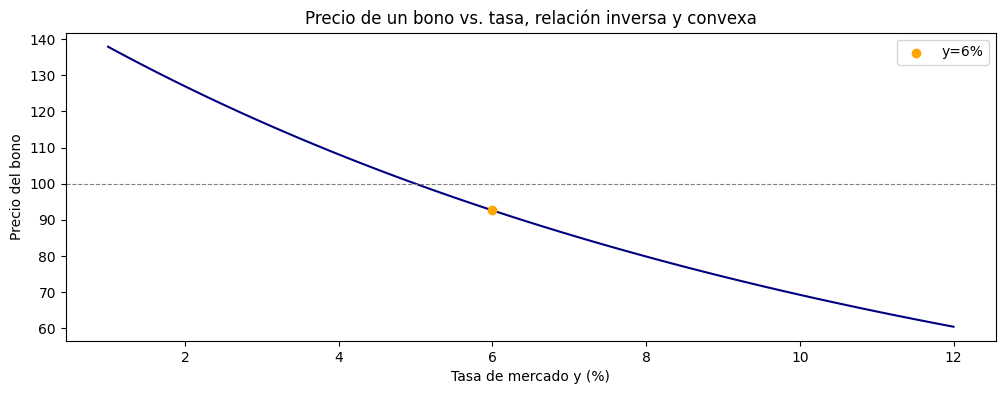

In [10]:
D_mac = np.sum(t * flujos / (1 + y)**t) / precio   # Macaulay: tiempo promedio ponderado (años)
D_mod = D_mac / (1 + y)                             # modificada: sensibilidad (%ΔP por Δy)
print(f'Duration de Macaulay : {D_mac:.2f} años   (el "centro de masa" temporal del bono)')
print(f'Duration modificada  : {D_mod:.2f}        (ΔP/P por cada 1pp que sube la tasa)')

# Curva precio-tasa: el precio como función de la tasa
ys = np.linspace(0.01, 0.12, 100)
precios = [np.sum(flujos / (1 + r)**t) for r in ys]

plt.plot(ys * 100, precios, color='navy')
plt.axhline(face, color='gray', ls='--', lw=0.8)
plt.scatter([y * 100], [precio], color='orange', zorder=5, label=f'y={y:.0%}')
plt.xlabel('Tasa de mercado y (%)'); plt.ylabel('Precio del bono')
plt.title('Precio de un bono vs. tasa, relación inversa y convexa')
plt.legend(); plt.show()

### ¿Alcanza la aproximación lineal? Repreciemos de verdad

$D_{mod}$ es la pendiente de la recta TANGENTE a la curva de arriba en $y=6\%$, exacta para
un cambio infinitesimal de tasa. Probemos con un salto de 100bp (1 punto porcentual, grande) y
comparemos contra repreciar el bono desde cero.

In [11]:
delta_y = 0.01
precio_real = np.sum(flujos / (1 + y + delta_y)**t)      # repreciar de cero, sin aproximar
caida_real = (precio_real - precio) / precio

caida_aprox = -D_mod * delta_y                            # la aproximación lineal (duration)
precio_aprox = precio * (1 + caida_aprox)

print(f'Precio repreciado a y+1% ({y+delta_y:.0%})  : {precio_real:.2f}   (caída real: {caida_real:+.2%})')
print(f'Precio aproximado por duration        : {precio_aprox:.2f}   (caída aprox.: {caida_aprox:+.2%})')
print(f'\nError de la aproximación lineal: {precio_real - precio_aprox:+.2f}')
print('La duration SIEMPRE exagera la caída (y subestima la suba): la curva de arriba es convexa, no una recta.')

Precio repreciado a y+1% (7%)  : 85.95   (caída real: -7.22%)
Precio aproximado por duration        : 85.63   (caída aprox.: -7.57%)

Error de la aproximación lineal: +0.32
La duration SIEMPRE exagera la caída (y subestima la suba): la curva de arriba es convexa, no una recta.


### La convexidad

El error de 0.32 de arriba no es ruido: es el resto de la expansión de Taylor que cortamos al
quedarnos solo con la derivada primera (duration). El siguiente término trae la derivada
segunda: la **convexidad** $C$:

$$\frac{\Delta P}{P} \approx -\,D_{mod}\,\Delta y \;+\; \tfrac{1}{2}\,C\,\Delta y^2, \qquad
C = \frac{1}{P(1+y)^2}\sum_t t(t+1)\frac{CF_t}{(1+y)^t}$$

Mismo patrón que en física: la duration es la velocidad (primera derivada del precio respecto
de la tasa), la convexidad es la aceleración (segunda derivada).

In [12]:
C = np.sum(t * (t + 1) * flujos / (1 + y)**t) / (precio * (1 + y)**2)
print(f'Convexidad: {C:.2f}')

caida_cuadratica = -D_mod * delta_y + 0.5 * C * delta_y**2
precio_cuadratico = precio * (1 + caida_cuadratica)

print(f'\nCaída real:                  {caida_real:+.4%}')
print(f'Aproximación LINEAL (duration sola):     {caida_aprox:+.4%}   (precio {precio_aprox:.2f}, error {precio_real-precio_aprox:+.2f})')
print(f'Aproximación CUADRÁTICA (+ convexidad):  {caida_cuadratica:+.4%}   (precio {precio_cuadratico:.2f}, error {precio_real-precio_cuadratico:+.2f})')
print('\nEl segundo término cierra casi todo el error: de +0.32 a +0.01 en el precio.')

Convexidad: 72.57

Caída real:                  -7.2184%
Aproximación LINEAL (duration sola):     -7.5684%   (precio 85.63, error +0.32)
Aproximación CUADRÁTICA (+ convexidad):  -7.2056%   (precio 85.96, error -0.01)

El segundo término cierra casi todo el error: de +0.32 a +0.01 en el precio.


### YTM: tasa implícita en un precio
En la práctica observás el **precio** y querés la tasa que lo explica: el *Yield to Maturity*.
Es la $y^*$ que resuelve

$$P_{\text{mercado}} = \sum_{t=1}^{T} \frac{CF_t}{(1+y^*)^t}$$

No hay fórmula cerrada → se resuelve numéricamente.

In [13]:
precio_mkt = 95.0
f = lambda r: np.sum(flujos / (1 + r)**t) - precio_mkt
ytm = brentq(f, 1e-6, 1.0)
print(f'Un bono que cotiza a {precio_mkt} tiene un YTM de {ytm:.3%}')

Un bono que cotiza a 95.0 tiene un YTM de 5.669%


---
# Ejercicio 3, Curvas: calibrar NSS (y bootstrapear) sobre datos

La tasa no es un número: es una **función del plazo** $r(T)$. El mercado solo muestra puntos sueltos
(los bonos que cotizan), queremos la curva completa. El modelo **Nelson-Siegel-Svensson** la resume
en 6 parámetros:

$$r(T) = \beta_0 + \beta_1 f(T,\lambda_1) + \beta_2\, g(T,\lambda_1) + \beta_3\, g(T,\lambda_2)$$

Calibrar = optimizar: **mínimos cuadrados no lineales** con `scipy`:

$$\min_{\beta,\lambda}\ \sum_i \left[r_{obs}(T_i) - r(T_i;\beta,\lambda)\right]^2$$

Mismo flujo que ajustar un modelo en física: datos → modelo paramétrico → optimización.

Lo hacemos con datos en vivo, y para el Tesoro por **dos caminos distintos**:
- **Tesoro EE.UU.**: 11 puntos de FRED (las series `DGS*`, sin API key) → **NSS** (ajuste directo,
  6 parámetros) **y bootstrapping** (extracción plazo por plazo, la receta de la teórica §6), las
  comparamos.
- **Globales argentinos**: TIRs en vivo de los GD29-GD46 en dólares (bonistas.com) → acá son
  solo 6 puntos, así que calibramos **Nelson-Siegel de 4 parámetros**, con 6 parámetros y
  6 puntos no se ajusta un modelo: se interpola (regla general: parámetros < puntos).

El spread entre ambas curvas soberanas es el **riesgo país** como función del plazo.

[datos en vivo (FRED, 2026-09-03)]
β₀-β₃: [ 5.604 -1.767 -1.383 -2.74 ]   λ₁,λ₂: [0.429 2.749]


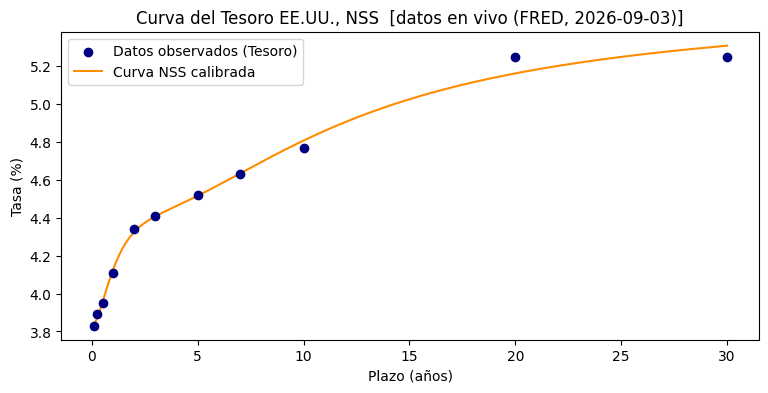

In [14]:
from scipy.optimize import minimize
import requests

# ── La curva del Tesoro EN VIVO, FRED, sin API key (respaldo fechado dic-2024) ──
FRED_IDS = {1/12: 'DGS1MO', 3/12: 'DGS3MO', 6/12: 'DGS6MO', 1: 'DGS1', 2: 'DGS2',
            3: 'DGS3', 5: 'DGS5', 7: 'DGS7', 10: 'DGS10', 20: 'DGS20', 30: 'DGS30'}
try:
    puntos = {}
    for T_, sid in FRED_IDS.items():
        r_ = requests.get(f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}', timeout=15)
        s_ = pd.read_csv(pd.io.common.StringIO(r_.text), parse_dates=['observation_date']).dropna()
        puntos[T_] = float(s_.iloc[-1][sid])
    fuente_usa = f"datos en vivo (FRED, {s_.iloc[-1]['observation_date'].date()})"
except Exception as e:
    fuente_usa = f'⚠ no hay datos ({e})'

mats = np.array(list(puntos.keys()))
ylds = np.array(list(puntos.values()))
print(f'[{fuente_usa}]')

def nss(T, b0, b1, b2, b3, l1, l2):
    f1 = (1 - np.exp(-T/l1)) / (T/l1)
    f2 = f1 - np.exp(-T/l1)
    f3 = (1 - np.exp(-T/l2)) / (T/l2) - np.exp(-T/l2)
    return b0 + b1*f1 + b2*f2 + b3*f3

res = minimize(lambda p: np.sum((nss(mats, *p) - ylds)**2),
               x0=[4, -1, 1, 1, 2, 5], method='L-BFGS-B',
               bounds=[(0, 20), (-15, 15), (-15, 15), (-15, 15), (0.1, 10), (0.1, 15)])
print('β₀-β₃:', res.x[:4].round(3), '  λ₁,λ₂:', res.x[4:].round(3))

T_fine = np.linspace(0.05, 30, 500)
plt.figure(figsize=(9, 4))
plt.scatter(mats, ylds, color='navy', zorder=3, label='Datos observados (Tesoro)')
plt.plot(T_fine, nss(T_fine, *res.x), color='darkorange', label='Curva NSS calibrada')
plt.xlabel('Plazo (años)'); plt.ylabel('Tasa (%)'); plt.legend()
plt.title(f'Curva del Tesoro EE.UU., NSS  [{fuente_usa}]')
plt.show()

   plazo   par yield  spot bootstrapeado
   0.08a       3.83%              3.830%
   0.25a       3.89%              3.890%
   0.50a       3.95%              3.950%
   1.00a       4.11%              4.110%
   2.00a       4.34%              4.251%
   3.00a       4.41%              4.321%
   5.00a       4.52%              4.434%
   7.00a       4.63%              4.550%
  10.00a       4.77%              4.708%
  20.00a       5.25%              5.472%
  30.00a       5.25%              5.125%


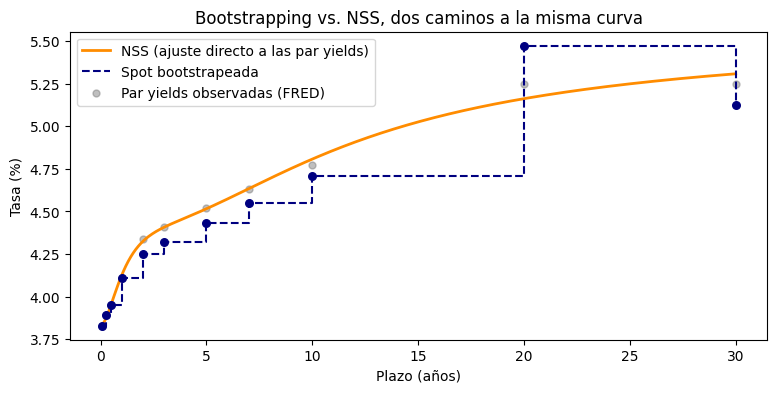


Diferencia máxima |spot bootstrapeada − NSS|: 0.311pp (en T=20.0a)
Se parecen porque la curva de hoy tiene poca curvatura, con una curva más empinada
o más "jorobada", la brecha entre ajustar directo (NSS) y extraer de verdad
(bootstrapping) se nota mucho más. Ambas son legítimas: NSS da una curva suave y
fácil de diferenciar (forward, §6 teórica); bootstrapping es exacta en los puntos
observados pero necesita interpolar los plazos que el mercado no cotiza directo.


In [15]:
# ── Bootstrapping: extraer la curva SPOT "de verdad" (no solo ajustar NSS a las yields) ──
# Las DGS de FRED son yields A LA PAR (Treasury Constant Maturity): la tasa de un bono
# hipotético que hoy cotiza a 100. Arriba, NSS las ajustó DIRECTO, tratándolas como si ya
# fueran spot, una aproximación común pero aproximación al fin. El bootstrapping (§6 de
# la teórica) las extrae de verdad, plazo por plazo, a partir de la ecuación de un bono:

def bootstrap_spot(mats, ylds):
    orden = np.argsort(mats)
    mats_o, ylds_o = mats[orden], ylds[orden]
    spot = {}                                            # T -> tasa spot (%) ya despejada
    for T_, y_ in zip(mats_o, ylds_o):
        if T_ <= 1:
            spot[T_] = y_                                 # letra: cupón cero, spot = yield directo
            continue
        conocidos = np.array(sorted(spot.keys()))
        r_interp = lambda t: np.interp(t, conocidos, [spot[k] for k in conocidos])
        anios_cupon = np.arange(1, int(np.ceil(T_)))      # 1, 2, ..., T-1 (cupones antes del final)
        vp_cupones = sum(y_ * np.exp(-r_interp(k)/100 * k) for k in anios_cupon)
        # bono anual a la par, cupón = y_: 100 = vp_cupones + (100+y_)·exp(-r(T)/100·T) → despejar r(T)
        spot[T_] = -100/T_ * np.log((100 - vp_cupones) / (100 + y_))
    Ts = np.array(sorted(spot.keys()))
    return Ts, np.array([spot[t] for t in Ts])

mats_spot, spot_boot = bootstrap_spot(mats, ylds)
par_por_plazo = dict(zip(mats, ylds))

print(f'{"plazo":>8}{"par yield":>12}{"spot bootstrapeado":>20}')
for t_, r_ in zip(mats_spot, spot_boot):
    print(f'{t_:>7.2f}a{par_por_plazo[t_]:>11.2f}%{r_:>19.3f}%')

plt.figure(figsize=(9, 4))
plt.plot(T_fine, nss(T_fine, *res.x), color='darkorange', lw=2, label='NSS (ajuste directo a las par yields)')
plt.step(mats_spot, spot_boot, where='post', color='navy', lw=1.5, ls='--', label='Spot bootstrapeada')
plt.scatter(mats_spot, spot_boot, color='navy', zorder=3, s=30)
plt.scatter(mats, ylds, color='gray', alpha=0.5, s=25, label='Par yields observadas (FRED)')
plt.xlabel('Plazo (años)'); plt.ylabel('Tasa (%)'); plt.legend()
plt.title('Bootstrapping vs. NSS, dos caminos a la misma curva')
plt.show()

dif = spot_boot - nss(mats_spot, *res.x)
i_max = np.argmax(np.abs(dif))
print(f'\nDiferencia máxima |spot bootstrapeada − NSS|: {np.abs(dif[i_max]):.3f}pp (en T={mats_spot[i_max]:.1f}a)')
print('Se parecen porque la curva de hoy tiene poca curvatura, con una curva más empinada')
print('o más "jorobada", la brecha entre ajustar directo (NSS) y extraer de verdad')
print('(bootstrapping) se nota mucho más. Ambas son legítimas: NSS da una curva suave y')
print('fácil de diferenciar (forward, §6 teórica); bootstrapping es exacta en los puntos')
print('observados pero necesita interpolar los plazos que el mercado no cotiza directo.')

[datos en vivo (bonistas.com)]
  GD29D: vence 2029-07-09  (T=2.8 años)  TIR 5.50%
  GD30D: vence 2030-07-09  (T=3.8 años)  TIR 6.39%
  GD35D: vence 2035-07-09  (T=8.8 años)  TIR 9.27%
  GD38D: vence 2038-01-09  (T=11.4 años)  TIR 9.00%
  GD41D: vence 2041-07-09  (T=14.9 años)  TIR 9.39%
  GD46D: vence 2046-07-09  (T=19.9 años)  TIR 9.27%

Spread promedio vs USA (3-20 años): 3.9pp, el riesgo país como función del plazo


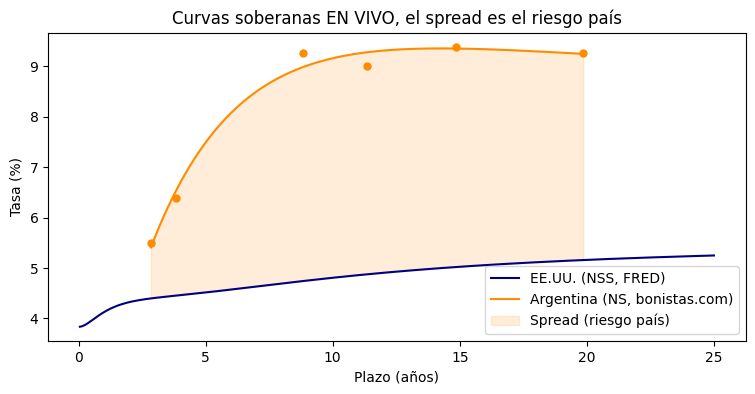

In [16]:
import datetime as dt

# ── Globales argentinos en USD EN VIVO, bonistas.com, sin API key ────────────
# Los vencimientos son contractuales (fijos desde la reestructuración de 2020):
VENC = {'GD29D': dt.date(2029, 7, 9), 'GD30D': dt.date(2030, 7, 9),
        'GD35D': dt.date(2035, 7, 9), 'GD38D': dt.date(2038, 1, 9),
        'GD41D': dt.date(2041, 7, 9), 'GD46D': dt.date(2046, 7, 9)}
hoy = dt.date.today()
mats_ar = np.array([(VENC[n] - hoy).days / 365 for n in VENC])

try:
    r_ = requests.get('https://bonistas.com/api/bonds', timeout=15,
                      headers={'User-Agent': 'Mozilla/5.0'})
    tirs = {}
    for b in r_.json():                      # la API repite cada bono (varios plazos de liquidación)
        if b.get('bond_name') in VENC and b.get('tir') is not None:
            tirs.setdefault(b['bond_name'], []).append(100 * float(b['tir']))
    ylds_ar = np.array([np.mean(tirs[n]) for n in VENC])       # TIR promedio por bono
    fuente_ar = 'datos en vivo (bonistas.com)'
except Exception as e:
    fuente_ar = f'⚠ no hay datos ({e})'

print(f'[{fuente_ar}]')
for n, m, y_ in zip(VENC, mats_ar, ylds_ar):
    print(f'  {n}: vence {VENC[n]}  (T={m:.1f} años)  TIR {y_:.2f}%')

# Con 6 puntos calibramos Nelson-Siegel (4 parámetros), NO NSS (6 parámetros):
# 6 parámetros con 6 puntos no ajustan, interpolan (sobreparametrización).
def ns(T, b0, b1, b2, l1):
    f1 = (1 - np.exp(-T/l1)) / (T/l1)
    f2 = f1 - np.exp(-T/l1)
    return b0 + b1*f1 + b2*f2

res_ar = minimize(lambda p: np.sum((ns(mats_ar, *p) - ylds_ar)**2),
                  x0=[8, -2, 2, 3], method='L-BFGS-B',
                  bounds=[(0, 30), (-15, 15), (-15, 15), (0.1, 15)])

# OJO: la curva argentina solo vale donde hay bonos (3 a 20 años), extrapolar
# un modelo paramétrico fuera de sus datos inventa números (acá daría un
# "riesgo país negativo" a 1 año que no existe: no hay Global más corto que 2029)
T_fine = np.linspace(mats_ar.min(), mats_ar.max(), 400)
spot_ar  = ns(T_fine, *res_ar.x)
spot_usa = nss(T_fine, *res.x)   # del bloque anterior
spread   = spot_ar - spot_usa
print(f'\nSpread promedio vs USA (3-20 años): {spread.mean():.1f}pp, el riesgo país como función del plazo')

plt.figure(figsize=(9, 4))
plt.plot(np.linspace(0.05, 25, 500), nss(np.linspace(0.05, 25, 500), *res.x), color='navy', label='EE.UU. (NSS, FRED)')
plt.plot(T_fine, spot_ar, color='darkorange', label='Argentina (NS, bonistas.com)')
plt.fill_between(T_fine, spot_usa, spot_ar, alpha=0.15, color='darkorange', label='Spread (riesgo país)')
plt.scatter(mats_ar, ylds_ar, color='darkorange', zorder=3, s=25)
plt.xlabel('Plazo (años)'); plt.ylabel('Tasa (%)'); plt.legend()
plt.title('Curvas soberanas EN VIVO, el spread es el riesgo país')
plt.show()

---
# Ejercicio 4: Valuar un IRS con la curva que acaban de calibrar

## La teoría en tres fórmulas (§7 de la teórica)

Un **Interest Rate Swap** (payer) paga tasa fija $c$ y recibe tasa flotante sobre un nocional $N$.
Su valor es la diferencia entre las dos patas, y ambas se calculan con la **curva de descuento**
$P(0,t) = e^{-r(t)\,t}$:

$$V_{payer} = \underbrace{N\,[1 - P(0,T)]}_{\text{pata flotante}} \; - \; \underbrace{N\,c\sum_{i} \delta_i\, P(0,t_i)}_{\text{pata fija}}$$

(la pata flotante vale $N[1-P(0,T)]$ porque flotante + devolución del nocional replica un bono a la par).

El **par swap rate** es la $c^*$ que hace $V = 0$:

$$c^* = \frac{1 - P(0,T)}{\sum_i \delta_i\, P(0,t_i)}$$

Y el **DV01** es la sensibilidad a 1bp de movimiento paralelo de la curva:
$\mathrm{DV01} = \frac{V(+1bp) - V(-1bp)}{2}$.

## El plan: el pipeline completo de tasas en una sola sesión

Acá está la gracia de este ejercicio: **la curva de descuento es la NSS del Tesoro que
calibraron recién en el Ejercicio 3** (los 11 puntos de FRED). Calibrar la curva → usarla
para valuar el derivado de tasas más grande del mundo , 
ese pipeline es exactamente lo que hace un desk de rates todos los días.

In [17]:
# ── La curva de descuento es la NSS del Ejercicio 3 (res.x, ya calibrada) ────
r_curve = lambda t: nss(np.asarray(t, dtype=float), *res.x)          # tasa spot en %, plazo en años
P = lambda t, shift_bp=0.0: np.exp(-(r_curve(t) + shift_bp/100)/100 * np.asarray(t, dtype=float))

N_swap, T_swap = 10_000_000, 5            # USD 10M, 5 años, pagos anuales (δ=1)
fechas_swap = np.arange(1, T_swap + 1)

def valor_payer(c, shift_bp=0.0):
    """Valor del swap payer: recibe flotante, paga fija c (c en decimal)."""
    pata_flotante = N_swap * (1 - P(T_swap, shift_bp))
    pata_fija     = N_swap * c * np.sum(P(fechas_swap, shift_bp))
    return pata_flotante - pata_fija

# Par swap rate: la c que hace V = 0
c_par = (1 - P(T_swap)) / np.sum(P(fechas_swap))
print(f'Par swap rate 5 años : {c_par*100:.3f}%   (comparar con la spot a 5a: {r_curve(5.0):.3f}%)')
print(f'Chequeo V(c_par)     : {valor_payer(c_par):+,.2f} USD  (debe ser ≈ 0)')

# MTM: entramos al swap a c_par y la curva se mueve en paralelo ±50bp
print(f'\nMTM del payer si la curva sube  +50bp: {valor_payer(c_par, +50):+,.0f} USD')
print(f'MTM del payer si la curva baja  -50bp: {valor_payer(c_par, -50):+,.0f} USD')

# DV01: diferencia central con ±1bp
dv01 = (valor_payer(c_par, +1) - valor_payer(c_par, -1)) / 2
print(f'\nDV01 = {dv01:+,.0f} USD por bp, equivale a un bono de duración '
      f'{abs(dv01)/N_swap*10_000:.2f} años, sin usar un dólar de capital hoy')

Par swap rate 5 años : 4.607%   (comparar con la spot a 5a: 4.516%)
Chequeo V(c_par)     : +0.00 USD  (debe ser ≈ 0)

MTM del payer si la curva sube  +50bp: +226,122 USD
MTM del payer si la curva baja  -50bp: -231,637 USD

DV01 = +4,577 USD por bp, equivale a un bono de duración 4.58 años, sin usar un dólar de capital hoy


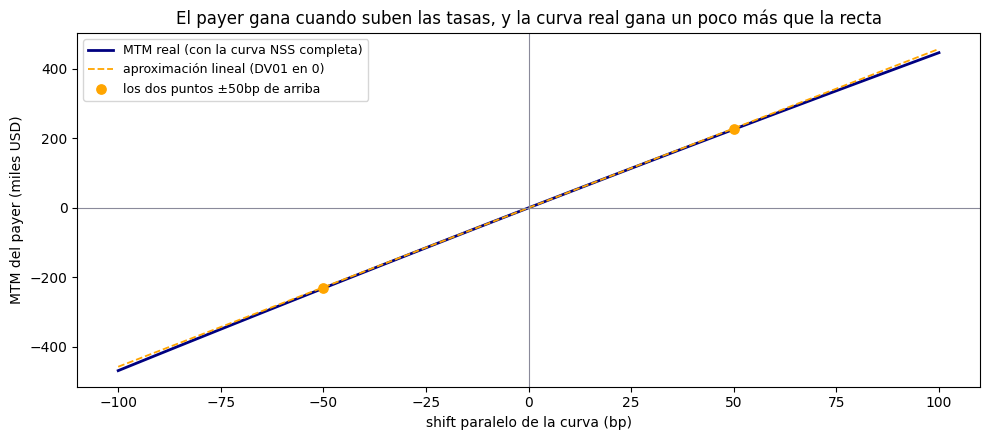

In [18]:
# ── La figura: MTM del payer contra un shift paralelo de la curva ────────────
shifts = np.linspace(-100, 100, 81)
mtm = np.array([valor_payer(c_par, s) for s in shifts])
tangente = dv01 * shifts                          # la aproximación lineal (DV01) para ver la convexidad

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(shifts, mtm/1e3, color='navy', lw=2, label='MTM real (con la curva NSS completa)')
ax.plot(shifts, tangente/1e3, color='orange', ls='--', lw=1.3, label='aproximación lineal (DV01 en 0)')
ax.scatter([-50, 50], [valor_payer(c_par,-50)/1e3, valor_payer(c_par,50)/1e3],
           color='orange', zorder=5, s=45, label='los dos puntos ±50bp de arriba')
ax.axhline(0, color='#8A8A9A', lw=0.8); ax.axvline(0, color='#8A8A9A', lw=0.8)
ax.set_xlabel('shift paralelo de la curva (bp)'); ax.set_ylabel('MTM del payer (miles USD)')
ax.set_title('El payer gana cuando suben las tasas, y la curva real gana un poco más que la recta')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


---
# Ejercicio 5, Covered Interest Parity: la tasa escondida en el precio de un futuro

## La idea, desde cero

Tenés \$1 y querés invertirlo **sin riesgo** hasta una fecha $T$. Hay dos rutas:

**Ruta A, quedarse en dólares:** lo colocás a la tasa americana $r_d$.
Al final tenés $e^{r_d T}$ dólares. Sin riesgo, obviamente.

**Ruta B, pasar por euros:** convertís hoy al spot $S$ (recibís $1/S$ euros), los colocás a
la tasa europea $r_f$, y, acá está la clave, **firmás HOY un contrato forward** que te fija
el tipo de cambio $F$ al que vas a reconvertir todo a dólares en $T$.
Al final tenés $\frac{e^{r_f T}}{S} \cdot F$ dólares. **También sin riesgo**: el tipo de cambio
al que salís quedó fijado de antemano, la posición está "cubierta" (*covered*).

Dos rutas sin riesgo que empiezan y terminan en dólares **tienen que rendir lo mismo**, si no,
pedís prestado por la barata, invertís por la cara, y ganás plata sin arriesgar nada. Ese
arbitraje fuerza la igualdad:

$$e^{r_d T} = \frac{F}{S}\,e^{r_f T} \quad\Longrightarrow\quad F = S\,e^{(r_d - r_f)\,T}$$

**Las dos consecuencias que son el corazón del ejercicio:**
1. El forward **no es una predicción** del dólar futuro, es aritmética de las tasas de HOY.
   Si $F > S$ no es que "el mercado espera que el euro suba": es que $r_d > r_f$, nada más.
2. La fórmula se puede **invertir**: observando $S$, $F$ y $r_d$, despejás la tasa europea
   $r_f$ que el mercado está usando. Eso hacemos hoy: **extraerle al futuro de euro del CME
   la tasa del BCE, sin mirar al BCE**, y comparar contra la verdadera (~2%).

## El plan

Los **futuros de euro del CME** (contratos `6E`, vencen el 3er miércoles de mar/jun/sep/dic)
funcionan como forwards observables. Extraemos la tasa implícita de dos maneras:

**Método A (el ingenuo):** spot + un futuro → $r_f = r_d - \ln(F/S)/T$.
Problema: el spot y el futuro cierran a **horas distintas**, unos pips de desfasaje, divididos
por un $T$ chico, se amplifican a decenas de puntos básicos. Lo vamos a ver fallar.

**Método B (el robusto):** dos futuros del mismo mercado, que liquidan a la misma hora:

$$r_d - r_f = \frac{\ln(F_2/F_1)}{T_2 - T_1}$$



[('6EZ26.CME', datetime.date(2026, 12, 16)), ('6EH27.CME', datetime.date(2027, 3, 17)), ('6EM27.CME', datetime.date(2027, 6, 16))]
[datos en vivo (Yahoo Finance)]
Spot EURUSD: 1.1621   |   tasa USD (^IRX): 3.76%

contrato           vence  T (años)        F  pips vs spot
6EZ26.CME     2026-12-16      0.28   1.1654           +33
6EH27.CME     2027-03-17      0.53   1.1695           +74
6EM27.CME     2027-06-16      0.78   1.1736          +115


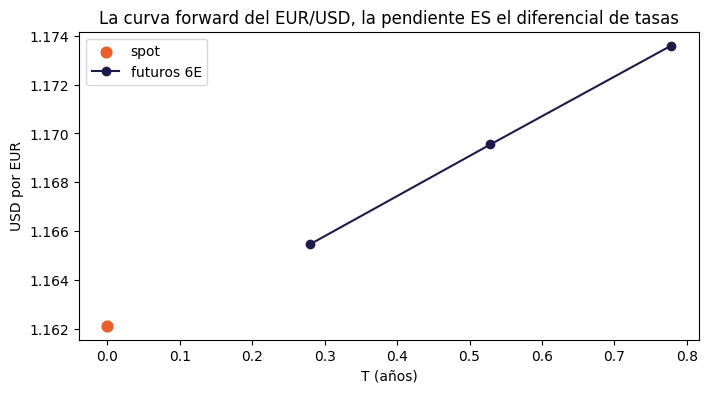

In [19]:
import datetime as dt

MES_CODIGO = {3: 'H', 6: 'M', 9: 'U', 12: 'Z'}

def imm_siguientes(hoy, n=3):
    """Próximos n vencimientos IMM (3er miércoles de mar/jun/sep/dic) con su ticker CME."""
    out = []
    for anio in (hoy.year, hoy.year + 1):
        for mes in (3, 6, 9, 12):
            d = dt.date(anio, mes, 15)
            while d.weekday() != 2:              # 2 = miércoles
                d += dt.timedelta(days=1)
            if d > hoy + dt.timedelta(days=20):  # evitar el contrato a punto de vencer
                out.append((f'6E{MES_CODIGO[mes]}{str(anio)[2:]}.CME', d))
    return out[:n]

hoy = dt.date.today()
contratos = imm_siguientes(hoy)
print(contratos)

# ── Datos en vivo, con respaldo por si Yahoo falla ────────────────────────────
try:
    S     = float(yf.Ticker('EURUSD=X').history(period='5d')['Close'].iloc[-1])
    r_usd = float(yf.Ticker('^IRX').history(period='5d')['Close'].iloc[-1]) / 100
    futuros = []
    for tk, venc in contratos:
        F = float(yf.Ticker(tk).history(period='5d')['Close'].iloc[-1])
        futuros.append((tk, venc, F, (venc - hoy).days / 365))
    fuente = 'datos en vivo (Yahoo Finance)'
except Exception as e:
    fuente = f'⚠ no hay datos ({e})'

print(f'[{fuente}]')
print(f'Spot EURUSD: {S:.4f}   |   tasa USD (^IRX): {r_usd:.2%}\n')
print(f'{"contrato":<12}{"vence":>12}{"T (años)":>10}{"F":>9}{"pips vs spot":>14}')
for tk, venc, F, T in futuros:
    print(f'{tk:<12}{str(venc):>12}{T:>10.2f}{F:>9.4f}{(F-S)*1e4:>+14.0f}')

# La curva forward del euro: si F crece con T, el mercado "devuelve" tasa al que tiene euros
plt.figure(figsize=(8, 4))
plt.scatter([0], [S], color='#E8602C', s=60, zorder=3, label='spot')
plt.plot([f[3] for f in futuros], [f[2] for f in futuros], 'o-', color='#1E1B4B', label='futuros 6E')
plt.xlabel('T (años)'); plt.ylabel('USD por EUR')
plt.title('La curva forward del EUR/USD, la pendiente ES el diferencial de tasas')
plt.legend(); plt.show()

In [20]:
# ── Método A (ingenuo): spot + primer futuro ──────────────────────────────────
tk1, venc1, F1, T1 = futuros[0]
r_eur_A = r_usd - np.log(F1/S)/T1

# ── Método B (robusto): dos futuros, sin spot ─────────────────────────────────
tk2, venc2, F2, T2 = futuros[-1]
dif_impl = np.log(F2/F1) / (T2 - T1)      # r_usd − r_eur implícito entre T1 y T2
r_eur_B  = r_usd - dif_impl

r_eur_ref = 0.02188        # referencia BCE / €STR  BUSCAR CUANTO VALE HOY!

print(f'Método A (spot + {tk1}):')
print(f'   r_EUR implícita = {r_eur_A:.2%}   → desvío vs BCE: {(r_eur_A-r_eur_ref)*1e4:+.0f} bp')
print(f'   Sensibilidad: 1 pip de desfasaje spot/futuro mueve la tasa {1e-4/(S*T1)*1e4:.0f} bp, frágil\n')

print(f'Método B ({tk1} vs {tk2}, sin spot):')
print(f'   diferencial implícito r_USD − r_EUR = {dif_impl:.2%}')
print(f'   r_EUR implícita = {r_eur_B:.2%}   → desvío vs BCE: {(r_eur_B-r_eur_ref)*1e4:+.0f} bp\n')

print('El método B usa dos precios que liquidan a la MISMA hora en el MISMO mercado:')
print('el spot (y su desfasaje horario) desaparece de la cuenta. La CIP funciona, ')
print('cuando se la mide bien.')

Método A (spot + 6EZ26.CME):
   r_EUR implícita = 2.73%   → desvío vs BCE: +54 bp
   Sensibilidad: 1 pip de desfasaje spot/futuro mueve la tasa 3 bp, frágil

Método B (6EZ26.CME vs 6EM27.CME, sin spot):
   diferencial implícito r_USD − r_EUR = 1.40%
   r_EUR implícita = 2.36%   → desvío vs BCE: +17 bp

El método B usa dos precios que liquidan a la MISMA hora en el MISMO mercado:
el spot (y su desfasaje horario) desaparece de la cuenta. La CIP funciona, 
cuando se la mide bien.


---
# Ejercicio 6: El AL30 real, cupón escalonado + amortización progresiva

## La idea

El bono del Ejercicio 2 era un bono de juguete: cupón fijo, un solo pago de capital
al final. La realidad es más fea. El **AL30** (Bonar 2030, ley argentina, uno de los bonos
de la reestructuración de 2020) tiene dos complicaciones reales:

1. **Cupón escalonado (step-up)**: la tasa NO es constante, sube en escalones a lo largo
   de la vida del bono.
2. **Amortización progresiva**: el capital NO se devuelve todo junto al vencimiento — se
   devuelve en cuotas, empezando varios años antes del final.

Los términos exactos (contractuales, de la reestructuración 2020):

| | |
|---|---|
| Emisión | 4-sep-2020 |
| Vencimiento | 9-jul-2030 |
| Pagos | semestrales, 9-ene y 9-jul |
| Cupón | 0.125% (pago 1) → 0.50% (pagos 2-5) → 0.75% (pagos 6-13) → 1.75% (pagos 14-20) |
| Amortización | 0% hasta el pago 7 → 4% en el pago 8 (jul-2024) → 8% en cada pago del 9 al 20 |

El cupón de cada pago se calcula sobre el capital **residual** (lo que todavía no se
amortizó), no sobre el 100 original — otra vez la misma idea de "residual" que en el
DV01 y el par swap rate de la teórica (7).

Construimos el flujo de fondos EXACTO, pago por pago, y lo usamos para dos cosas: leer
cuánto queda de capital vivo hoy, y despejar la TIR de mercado con datos reales.


In [21]:
import datetime as dt

emision = dt.date(2020, 9, 4)
vencimiento = dt.date(2030, 7, 9)

# 20 fechas de pago semestrales: 9-ene y 9-jul, de 2021 al vencimiento
fechas = []
anio, mes = 2021, 1
while True:
    fechas.append(dt.date(anio, mes, 9))
    if (anio, mes) == (vencimiento.year, vencimiento.month):
        break
    mes, anio = (7, anio) if mes == 1 else (1, anio + 1)

def tasa_cupon(i):              # i = número de pago, 1-indexado. TNA vigente en ese pago.
    if i == 1:
        return 0.00125
    if i <= 5:
        return 0.0050
    if i <= 13:
        return 0.0075
    return 0.0175

def amort_pct(i):                # % del capital ORIGINAL que se amortiza en el pago i
    if i < 8:
        return 0.0
    if i == 8:
        return 0.04
    return 0.08

filas = []
residual = 100.0
for i, f in enumerate(fechas, start=1):
    cupon = residual * tasa_cupon(i) / 2      # semestral, 30/360 -> exactamente la mitad de la TNA
    amort = 100.0 * amort_pct(i)
    filas.append(dict(pago=i, fecha=f, tasa_anual=tasa_cupon(i), residual_antes=residual,
                       cupon=cupon, amortizacion=amort, flujo_total=cupon + amort))
    residual -= amort

cf = pd.DataFrame(filas)
print(f'{len(cf)} pagos, de {fechas[0]} a {fechas[-1]}')
print(f'Suma de amortizaciones: {cf.amortizacion.sum():.1f} (tiene que dar 100)')
print()
print(cf.to_string(index=False, formatters={
    'tasa_anual':      '{:.3%}'.format,
    'residual_antes':  '{:.2f}'.format,
    'cupon':           '{:.3f}'.format,
    'amortizacion':    '{:.2f}'.format,
    'flujo_total':     '{:.3f}'.format,
}))


20 pagos, de 2021-01-09 a 2030-07-09
Suma de amortizaciones: 100.0 (tiene que dar 100)

 pago      fecha tasa_anual residual_antes cupon amortizacion flujo_total
    1 2021-01-09     0.125%         100.00 0.062         0.00       0.062
    2 2021-07-09     0.500%         100.00 0.250         0.00       0.250
    3 2022-01-09     0.500%         100.00 0.250         0.00       0.250
    4 2022-07-09     0.500%         100.00 0.250         0.00       0.250
    5 2023-01-09     0.500%         100.00 0.250         0.00       0.250
    6 2023-07-09     0.750%         100.00 0.375         0.00       0.375
    7 2024-01-09     0.750%         100.00 0.375         0.00       0.375
    8 2024-07-09     0.750%         100.00 0.375         4.00       4.375
    9 2025-01-09     0.750%          96.00 0.360         8.00       8.360
   10 2025-07-09     0.750%          88.00 0.330         8.00       8.330
   11 2026-01-09     0.750%          80.00 0.300         8.00       8.300
   12 2026-07-09     0.7

In [22]:
# ── Cuánto queda vivo HOY, y la TIR que implica el precio de mercado ─────────
hoy = dt.date.today()
futuros = cf[cf.fecha > hoy].reset_index(drop=True)
pasados = cf[cf.fecha <= hoy]

residual_hoy = futuros.iloc[0]['residual_antes']
print(f'Hoy ({hoy}): ya se pagaron {len(pasados)} de los {len(cf)} cupones/amortizaciones.')
print(f'Capital residual vivo: {residual_hoy:.1f} de 100 originales '
      f'({100 - residual_hoy:.0f} ya se devolvió).')
print(f'Próximo pago: {futuros.iloc[0]["fecha"]}, por {futuros.iloc[0]["flujo_total"]:.3f}')

# Precio real de mercado (AL30D, ley argentina, liquidación en USD) en vivo
try:
    r_ = requests.get('https://bonistas.com/api/bonds', timeout=15,
                      headers={'User-Agent': 'Mozilla/5.0'})
    al30d = [b for b in r_.json() if b.get('bond_name') == 'AL30D' and b.get('last_price')]
    precio_mkt = np.mean([b['last_price'] for b in al30d])
    tir_mkt = np.mean([b['tir'] for b in al30d])
    fuente = 'datos en vivo (bonistas.com)'
except Exception as e:
    fuente = f'⚠ no hay datos ({e})'

print(f'\n[{fuente}] AL30D: precio {precio_mkt:.2f}  |  TIR reportada por el mercado: {tir_mkt*100:.2f}%')

# Nuestra propia TIR: la tasa que descuenta el flujo EXACTO (solo los pagos futuros)
# al precio de mercado observado. Mismo brentq del Ejercicio 2, misma lógica.
def pv(y):
    t = (pd.to_datetime(futuros['fecha']) - pd.Timestamp(hoy)).dt.days / 365
    return float((futuros['flujo_total'] / (1 + y) ** t).sum()) - precio_mkt

y_impl = brentq(pv, 0.001, 1.0)
print(f'TIR implícita (nuestro flujo exacto vs. precio de mercado): {y_impl*100:.2f}%')
print(f'Diferencia contra la TIR que reporta el mercado: {(y_impl - tir_mkt)*10000:+.0f} bp')


Hoy (2026-09-05): ya se pagaron 12 de los 20 cupones/amortizaciones.
Capital residual vivo: 64.0 de 100 originales (36 ya se devolvió).
Próximo pago: 2027-01-09, por 8.240

[datos en vivo (bonistas.com)] AL30D: precio 55.95  |  TIR reportada por el mercado: 8.42%
TIR implícita (nuestro flujo exacto vs. precio de mercado): 8.66%
Diferencia contra la TIR que reporta el mercado: +24 bp


In [23]:
# ── Precio limpio vs. precio sucio: el interés corrido ───────────────────────
# El precio de mercado (55.33) es "limpio": no incluye lo que ya se devengó desde
# el último cupón. Para descontar flujos FUTUROS contra un precio de HOY hay que
# sumarle ese interés corrido -> precio "sucio", el que de verdad se paga al comprar.
ultimo_cupon = pasados.iloc[-1]
dias_transcurridos = (hoy - ultimo_cupon['fecha']).days
dias_periodo = (futuros.iloc[0]['fecha'] - ultimo_cupon['fecha']).days
interes_corrido = residual_hoy * futuros.iloc[0]['tasa_anual'] / 2 * (dias_transcurridos / dias_periodo)

precio_sucio = precio_mkt + interes_corrido
print(f'Días desde el último cupón ({ultimo_cupon["fecha"]}): {dias_transcurridos} de {dias_periodo}')
print(f'Interés corrido: {interes_corrido:.4f}  ->  precio sucio: {precio_sucio:.4f} (vs. limpio {precio_mkt:.2f})')

def pv_sucio(y):
    t = (pd.to_datetime(futuros['fecha']) - pd.Timestamp(hoy)).dt.days / 365
    return float((futuros['flujo_total'] / (1 + y) ** t).sum()) - precio_sucio

y_sucio = brentq(pv_sucio, 0.001, 1.0)
print(f'\nTIR con precio limpio (como antes): {y_impl*100:.3f}%   (gap: {(y_impl-tir_mkt)*10000:+.0f} bp)')
print(f'TIR con precio sucio:               {y_sucio*100:.3f}%   (gap: {(y_sucio-tir_mkt)*10000:+.0f} bp)')
print('El interés corrido explica una parte de la brecha, no toda: el resto es')
print('convención de día (nosotros ACT/365, el cupón se devenga en 30/360) y la')
print('convención de settlement exacta que use el mercado.')


Días desde el último cupón (2026-07-09): 58 de 184
Interés corrido: 0.0757  ->  precio sucio: 56.0207 (vs. limpio 55.95)

TIR con precio limpio (como antes): 8.658%   (gap: +24 bp)
TIR con precio sucio:               8.584%   (gap: +17 bp)
El interés corrido explica una parte de la brecha, no toda: el resto es
convención de día (nosotros ACT/365, el cupón se devenga en 30/360) y la
convención de settlement exacta que use el mercado.
